# Phase 1: Raw Data Diagnosis (EDA)
## Exploratory Data Analysis - Hate Crimes & BH Incidents Dataset 2024

**Objective**: Detect errors, missing values and inconsistencies in decoded data (bh_decoded and ir_decoded) to provide evidence for why Data Preparation is needed.

**Method**: 
- Use `.info()`, `.describe()`, `.isna().sum()` to check data structure and quality
- Visualize raw data to demonstrate issues
- Summarize 5+ main issues that need handling in Phase 2
- Analyze both datasets: BH (Behavioral Health) and IR (Incident Reports)

---

## 1. Raw Data Status (Encoding Issues)

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import pickle

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create folder for images
os.makedirs('images_before', exist_ok=True)

# Load raw data (not decoded - for reference only)
print("Loading raw data files...")
try:
    with open('FINAL_BH_Agencies.csv', 'rb') as f:
        bh_raw = pickle.load(f)
    print("BH raw data loaded (pickle format)")
except:
    print("BH raw data: Reading as CSV (note: encoding issues expected)")
    try:
        bh_raw = pd.read_csv('FINAL_BH_Agencies.csv', encoding='latin-1')
    except:
        bh_raw = None

try:
    with open('FINAL_IR_Incidents.csv', 'rb') as f:
        ir_raw = pickle.load(f)
    print("IR raw data loaded (pickle format)")
except:
    print("IR raw data: Reading as CSV (note: encoding issues expected)")
    try:
        ir_raw = pd.read_csv('FINAL_IR_Incidents.csv', encoding='latin-1')
    except:
        ir_raw = None

# Load decoded data for analysis
print("\nLoading decoded data for analysis...")
bh_decoded = pd.read_csv('FINAL_BH_Agencies.csv', encoding='utf-8')
ir_decoded = pd.read_csv('FINAL_IR_Incidents.csv', encoding='utf-8')

print("\nDecoded data loaded successfully!")
print(f"  BH Agencies - Rows: {bh_decoded.shape[0]:,}, Columns: {bh_decoded.shape[1]}")
print(f"  IR Incidents - Rows: {ir_decoded.shape[0]:,}, Columns: {ir_decoded.shape[1]}")

Loading raw data files...
BH raw data: Reading as CSV (note: encoding issues expected)
IR raw data: Reading as CSV (note: encoding issues expected)


/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_38989/2654006343.py:25: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  bh_raw = pd.read_csv('FINAL_BH_Agencies.csv', encoding='latin-1')



Loading decoded data for analysis...

Decoded data loaded successfully!
  BH Agencies - Rows: 104,544, Columns: 27
  IR Incidents - Rows: 46,675, Columns: 37

Decoded data loaded successfully!
  BH Agencies - Rows: 104,544, Columns: 27
  IR Incidents - Rows: 46,675, Columns: 37


/var/folders/4q/n_hx7pyx1z37j_2hv5nqwgnc0000gn/T/ipykernel_38989/2654006343.py:42: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  bh_decoded = pd.read_csv('FINAL_BH_Agencies.csv', encoding='utf-8')


## 2. Decoded Data Structure Exploration - BH Dataset

In [39]:
print("="*80)
print("RAW DATA STATUS - ENCODING ISSUES (Not suitable for analysis)")
print("="*80)

if bh_raw is not None:
    print("\nBH Agencies Raw Data (encoding=latin-1):")
    print(f"  Shape: {bh_raw.shape}")
    print("\n  First 3 rows (note: encoding issues may cause unreadable characters):")
    print(bh_raw.head(3))
else:
    print("\nBH raw data: Unable to load (severe encoding issues)")

print("\n" + "="*80)

if ir_raw is not None:
    print("\nIR Incidents Raw Data (encoding=latin-1):")
    print(f"  Shape: {ir_raw.shape}")
    print("\n  First 3 rows (note: encoding issues may cause unreadable characters):")
    print(ir_raw.head(3))
else:
    print("\nIR raw data: Unable to load (severe encoding issues)")

print("\n" + "-"*80)
print("CONCLUSION: Raw data files have encoding issues and are not readable.")
print("Using decoded versions (utf-8) for actual analysis below.")
print("-"*80)

RAW DATA STATUS - ENCODING ISSUES (Not suitable for analysis)

BH Agencies Raw Data (encoding=latin-1):
  Shape: (104544, 27)

  First 3 rows (note: encoding issues may cause unreadable characters):
   agency_id agency_name       city  state_code state_abbr state_name  \
0  AL0370100   ABBEVILLE  ABBEVILLE           1         AL    Alabama   
1  AL0370100   ABBEVILLE  ABBEVILLE           1         AL    Alabama   
2  AL0370100   ABBEVILLE  ABBEVILLE           1         AL    Alabama   

   region_code region  division_code            division  ...  \
0          3.0  South            6.0  East South Central  ...   
1          3.0  South            6.0  East South Central  ...   
2          3.0  South            6.0  East South Central  ...   

   is_nibrs_reporting date_agency_added date_nibrs_started date_inactive  \
0                True               NaN         2020-01-01           NaN   
1                True               NaN         2020-01-01           NaN   
2                Tr

In [40]:
print("="*80)
print("BH AGENCIES DATA - OVERVIEW")
print("="*80)
bh_decoded.info()

BH AGENCIES DATA - OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104544 entries, 0 to 104543
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   agency_id              104544 non-null  object 
 1   agency_name            104544 non-null  object 
 2   city                   89424 non-null   object 
 3   state_code             104544 non-null  int64  
 4   state_abbr             104544 non-null  object 
 5   state_name             104544 non-null  object 
 6   region_code            103164 non-null  float64
 7   region                 103164 non-null  object 
 8   division_code          103164 non-null  float64
 9   division               104544 non-null  object 
 10  agency_type_code       101012 non-null  float64
 11  agency_type            101012 non-null  object 
 12  population_group_code  103164 non-null  object 
 13  population_group       103164 non-null  object 
 14  populati

In [41]:
print("\n" + "="*80)
print("BH AGENCIES - BASIC STATISTICS (.describe())")
print("="*80)

print("\nNUMERIC COLUMNS:")
print(bh_decoded.describe().T)
print("\nCATEGORICAL COLUMNS:")
print(bh_decoded.describe(include='object').T)


BH AGENCIES - BASIC STATISTICS (.describe())

NUMERIC COLUMNS:
                        count          mean           std          min  \
state_code           104544.0  2.664375e+01  1.602728e+01     1.000000   
region_code          103164.0  2.438099e+00  9.643154e-01     0.000000   
division_code        103164.0  4.662091e+00  2.263286e+00     0.000000   
agency_type_code     101012.0  2.302657e+00  1.846274e+00     1.000000   
population           104544.0  1.308998e+04  8.202337e+04     0.000000   
population_previous  104544.0  0.000000e+00  0.000000e+00     0.000000   
date_agency_added         0.0           NaN           NaN          NaN   
reporting_year       104544.0  2.022500e+03  1.118039e+00  2021.000000   
county_code_1        104544.0  3.755843e+01  3.946892e+01     0.000000   
msa_code_1            96566.0  2.734508e+02  3.181481e+02     0.000000   
fips_county_codes     92348.0  3.703321e+07  2.078338e+09     1.000000   
years_since_nibrs     67364.0  1.268786e+01  1.0

In [42]:
print("\n" + "="*80)
print("BH AGENCIES - MISSING VALUES ANALYSIS")
print("="*80)

bh_missing_data = pd.DataFrame({
    'Column': bh_decoded.columns,
    'Missing Count': bh_decoded.isna().sum(),
    'Percentage (%)': (bh_decoded.isna().sum() / len(bh_decoded) * 100).round(2)
}).sort_values('Missing Count', ascending=False)

print(bh_missing_data.to_string(index=False))
print(f"\nTotal missing values in BH dataset: {bh_decoded.isna().sum().sum()}")


BH AGENCIES - MISSING VALUES ANALYSIS
               Column  Missing Count  Percentage (%)
    date_agency_added         104544          100.00
        date_inactive          83948           80.30
   is_nibrs_reporting          37180           35.56
    years_since_nibrs          37180           35.56
   date_nibrs_started          37180           35.56
                 city          15120           14.46
    fips_county_codes          12196           11.67
           msa_code_1           7978            7.63
     agency_type_code           3532            3.38
          agency_type           3532            3.38
population_group_code           1380            1.32
         is_core_city           1380            1.32
     population_group           1380            1.32
        division_code           1380            1.32
               region           1380            1.32
          region_code           1380            1.32
       reporting_year              0            0.00
       

## 3. IR Incidents Data Structure Exploration

In [43]:
print("\n" + "="*80)
print("IR INCIDENTS DATA - OVERVIEW")
print("="*80)
ir_decoded.info()


IR INCIDENTS DATA - OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46675 entries, 0 to 46674
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   agency_id                 46675 non-null  object
 1   incident_id               46675 non-null  object
 2   incident_date             46675 non-null  object
 3   agency_index              46675 non-null  int64 
 4   state_code                46675 non-null  int64 
 5   state_name                46675 non-null  object
 6   quarter_code              46675 non-null  int64 
 7   quarter                   46675 non-null  object
 8   data_source_code          37636 non-null  object
 9   data_source               37636 non-null  object
 10  offense_code              46675 non-null  object
 11  offense_description       46537 non-null  object
 12  location_code             46675 non-null  int64 
 13  location                  46088 non-null  obje

In [44]:
print("\n" + "="*80)
print("IR INCIDENTS - BASIC STATISTICS (.describe())")
print("="*80)

print("\nNUMERIC COLUMNS:")
print(ir_decoded.describe().T)
print("\nCATEGORICAL COLUMNS:")
print(ir_decoded.describe(include='object').T)


IR INCIDENTS - BASIC STATISTICS (.describe())

NUMERIC COLUMNS:
                            count          mean           std     min  \
agency_index              46675.0  51258.696283  29968.365395     0.0   
state_code                46675.0     23.782089     16.343266     1.0   
quarter_code              46675.0      2.547445      1.091025     1.0   
location_code             46675.0     21.837450     14.551841     1.0   
offense_victims           46675.0      1.147745      0.579298     1.0   
bias_code                 46675.0     26.617654     18.358838    11.0   
total_victims_reported    46675.0      0.985410      0.811351     0.0   
adult_victims             46675.0      0.837215      0.772807     0.0   
juvenile_victims          46675.0      0.128249      0.461165     0.0   
total_victims             46675.0      0.965463      0.821967     0.0   
total_offenders_reported  46675.0      0.868259      0.858739     0.0   
adult_offenders           46675.0      0.581275      0.6985

In [45]:
print("\n" + "="*80)
print("IR INCIDENTS - MISSING VALUES ANALYSIS")
print("="*80)

ir_missing_data = pd.DataFrame({
    'Column': ir_decoded.columns,
    'Missing Count': ir_decoded.isna().sum(),
    'Percentage (%)': (ir_decoded.isna().sum() / len(ir_decoded) * 100).round(2)
}).sort_values('Missing Count', ascending=False)

print(ir_missing_data.to_string(index=False))
print(f"\nTotal missing values in IR dataset: {ir_decoded.isna().sum().sum()}")


IR INCIDENTS - MISSING VALUES ANALYSIS
                  Column  Missing Count  Percentage (%)
      offender_ethnicity          20234           43.35
 offender_ethnicity_code          19241           41.22
        data_source_code           9039           19.37
             data_source           9039           19.37
                location            587            1.26
     offense_description            138            0.30
               agency_id              0            0.00
           total_victims              0            0.00
total_offenders_reported              0            0.00
         adult_offenders              0            0.00
      juvenile_offenders              0            0.00
         total_offenders              0            0.00
           offender_race              0            0.00
      offender_race_code              0            0.00
           adult_victims              0            0.00
                    year              0            0.00
        

In [46]:
print("\n" + "="*80)
print("DUPLICATE RECORDS ANALYSIS")
print("="*80)

bh_duplicates = bh_decoded.duplicated().sum()
ir_duplicates = ir_decoded.duplicated().sum()

print(f"BH Dataset - Total duplicate rows: {bh_duplicates}")
print(f"BH Dataset - Percentage: {(bh_duplicates / len(bh_decoded) * 100):.2f}%")

print(f"\nIR Dataset - Total duplicate rows: {ir_duplicates}")
print(f"IR Dataset - Percentage: {(ir_duplicates / len(ir_decoded) * 100):.2f}%")

if bh_duplicates > 0:
    print(f"\nBH - Example of duplicate rows:")
    print(bh_decoded[bh_decoded.duplicated(keep=False)].head(5))

if ir_duplicates > 0:
    print(f"\nIR - Example of duplicate rows:")
    print(ir_decoded[ir_decoded.duplicated(keep=False)].head(5))


DUPLICATE RECORDS ANALYSIS


BH Dataset - Total duplicate rows: 0
BH Dataset - Percentage: 0.00%

IR Dataset - Total duplicate rows: 2
IR Dataset - Percentage: 0.00%

IR - Example of duplicate rows:
      agency_id   incident_id incident_date  agency_index  state_code  \
5909  PA0320300  2W2MGURP8C1A    2021-07-12         19344          37   
5910  PA0320300  2W2MGURP8C1A    2021-07-12         19344          37   
7576  NY0303000  NM52RCTD1AEM    2021-09-04         15568          31   
7577  NY0303000  NM52RCTD1AEM    2021-09-04         15568          31   

        state_name  quarter_code quarter data_source_code data_source  ...  \
5909  Pennsylvania             3      Q3              NaN         NaN  ...   
5910  Pennsylvania             3      Q3              NaN         NaN  ...   
7576      New York             3      Q3              NaN         NaN  ...   
7577      New York             3      Q3              NaN         NaN  ...   

     total_offenders offender_race_code            offender_race  \
5909 

## 4. Detailed Issue Analysis - Comparison

In [72]:
print("="*80)
print("DATA QUALITY COMPARISON: BH vs IR Datasets")
print("="*80)

comparison_data = {
    'Metric': ['Total Records', 'Total Columns', 'Duplicate Rows', 'Missing Values', 'Data Size (MB)'],
    'BH Agencies': [
        f"{bh_decoded.shape[0]:,}",
        f"{bh_decoded.shape[1]}",
        f"{bh_decoded.duplicated().sum():,}",
        f"{bh_decoded.isna().sum().sum():,}",
        f"{bh_decoded.memory_usage(deep=True).sum() / 1e6:.2f}"
    ],
    'IR Incidents': [
        f"{ir_decoded.shape[0]:,}",
        f"{ir_decoded.shape[1]}",
        f"{ir_decoded.duplicated().sum():,}",
        f"{ir_decoded.isna().sum().sum():,}",
        f"{ir_decoded.memory_usage(deep=True).sum() / 1e6:.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

DATA QUALITY COMPARISON: BH vs IR Datasets

        Metric BH Agencies IR Incidents
 Total Records     104,544       46,675
 Total Columns          27           37
Duplicate Rows           0            2
Missing Values     350,670       58,278
Data Size (MB)       95.59        66.04

        Metric BH Agencies IR Incidents
 Total Records     104,544       46,675
 Total Columns          27           37
Duplicate Rows           0            2
Missing Values     350,670       58,278
Data Size (MB)       95.59        66.04


In [48]:
print("\n" + "="*80)
print("ISSUE 1: DATA TYPE AND FORMAT ANALYSIS")
print("="*80)

print("\n[BH Dataset] Data Types:")
print(bh_decoded.dtypes.value_counts())

print("\n[IR Dataset] Data Types:")
print(ir_decoded.dtypes.value_counts())

# Check for object columns (text data)
print("\n[BH] Object columns (potential encoding issues):")
bh_object_cols = bh_decoded.select_dtypes(include='object').columns.tolist()
print(f"  Total: {len(bh_object_cols)} columns")
for col in bh_object_cols[:5]:
    print(f"  - {col}: {bh_decoded[col].nunique()} unique values")

print("\n[IR] Object columns (potential encoding issues):")
ir_object_cols = ir_decoded.select_dtypes(include='object').columns.tolist()
print(f"  Total: {len(ir_object_cols)} columns")
for col in ir_object_cols[:5]:
    print(f"  - {col}: {ir_decoded[col].nunique()} unique values")


ISSUE 1: DATA TYPE AND FORMAT ANALYSIS

[BH Dataset] Data Types:
object     14
float64     7
int64       5
bool        1
Name: count, dtype: int64

[IR Dataset] Data Types:
object    20
int64     16
bool       1
Name: count, dtype: int64

[BH] Object columns (potential encoding issues):
  Total: 14 columns
  - agency_id: 26136 unique values
  - agency_name: 18658 unique values
  - city: 9024 unique values
  - state_abbr: 58 unique values
  - state_name: 57 unique values

[IR] Object columns (potential encoding issues):
  Total: 20 columns
  - agency_id: 6473 unique values
  - incident_id: 46383 unique values
  - incident_date: 1461 unique values
  - state_name: 53 unique values
  - quarter: 4 unique values


In [49]:
print("\n" + "="*80)
print("ISSUE 2: CATEGORICAL VALUE DISTRIBUTION")
print("="*80)

print("\n[BH Dataset] Top categorical columns:")
for col in bh_object_cols[:3]:
    print(f"\n  {col}:")
    print(f"    Unique values: {bh_decoded[col].nunique()}")
    print(f"    Top 5:")
    for val, count in bh_decoded[col].value_counts().head(5).items():
        pct = count / len(bh_decoded) * 100
        print(f"      - {str(val)[:40]:40s} : {count:6,d} ({pct:5.1f}%)")

print("\n" + "-"*80)
print("\n[IR Dataset] Top categorical columns:")
for col in ir_object_cols[:3]:
    print(f"\n  {col}:")
    print(f"    Unique values: {ir_decoded[col].nunique()}")
    print(f"    Top 5:")
    for val, count in ir_decoded[col].value_counts().head(5).items():
        pct = count / len(ir_decoded) * 100
        print(f"      - {str(val)[:40]:40s} : {count:6,d} ({pct:5.1f}%)")


ISSUE 2: CATEGORICAL VALUE DISTRIBUTION

[BH Dataset] Top categorical columns:

  agency_id:
    Unique values: 26136
    Top 5:
      - AL0370100                                :      4 (  0.0%)
      - OK0280100                                :      4 (  0.0%)
      - OK0310800                                :      4 (  0.0%)
      - OK0612300                                :      4 (  0.0%)
      - OK0610200                                :      4 (  0.0%)

  agency_name:
    Unique values: 18658
    Top 5:
      - DEPT OF AGRICULTURE AND CONSUM           :    268 (  0.3%)
      - DEPARTMENT OF ENVIRONMENTAL PR           :    268 (  0.3%)
      - OFFICE OF ATTORNEY GENERAL REG           :    268 (  0.3%)
      - WASHINGTON                               :    196 (  0.2%)
      - FRANKLIN                                 :    184 (  0.2%)

  city:
    Unique values: 9024
    Top 5:
      - FL                                       :  1,336 (  1.3%)
      - HARRISBURG                   

In [50]:
print("\n" + "="*80)
print("ISSUE 3: NUMERIC DISTRIBUTION AND OUTLIERS")
print("="*80)

# Get numeric columns
bh_numeric_cols = bh_decoded.select_dtypes(include=[np.number]).columns.tolist()
ir_numeric_cols = ir_decoded.select_dtypes(include=[np.number]).columns.tolist()

print("\n[BH Dataset] Numeric columns statistics:")
if bh_numeric_cols:
    for col in bh_numeric_cols[:5]:
        print(f"\n  {col}:")
        print(f"    Min: {bh_decoded[col].min()}, Max: {bh_decoded[col].max()}")
        print(f"    Mean: {bh_decoded[col].mean():.2f}, Median: {bh_decoded[col].median():.2f}")
        print(f"    Std: {bh_decoded[col].std():.2f}")
else:
    print("  No numeric columns found")

print("\n" + "-"*80)
print("\n[IR Dataset] Numeric columns statistics:")
if ir_numeric_cols:
    for col in ir_numeric_cols[:5]:
        print(f"\n  {col}:")
        print(f"    Min: {ir_decoded[col].min()}, Max: {ir_decoded[col].max()}")
        print(f"    Mean: {ir_decoded[col].mean():.2f}, Median: {ir_decoded[col].median():.2f}")
        print(f"    Std: {ir_decoded[col].std():.2f}")
else:
    print("  No numeric columns found")


ISSUE 3: NUMERIC DISTRIBUTION AND OUTLIERS

[BH Dataset] Numeric columns statistics:

  state_code:
    Min: 1, Max: 98
    Mean: 26.64, Median: 28.00
    Std: 16.03

  region_code:
    Min: 0.0, Max: 4.0
    Mean: 2.44, Median: 3.00
    Std: 0.96

  division_code:
    Min: 0.0, Max: 9.0
    Mean: 4.66, Median: 5.00
    Std: 2.26

  agency_type_code:
    Min: 1.0, Max: 8.0
    Mean: 2.30, Median: 1.00
    Std: 1.85

  population:
    Min: 0, Max: 8475387
    Mean: 13089.98, Median: 1396.00
    Std: 82023.37

--------------------------------------------------------------------------------

[IR Dataset] Numeric columns statistics:

  agency_index:
    Min: 0, Max: 104529
    Mean: 51258.70, Median: 53318.00
    Std: 29968.37

  state_code:
    Min: 1, Max: 98
    Mean: 23.78, Median: 24.00
    Std: 16.34

  quarter_code:
    Min: 1, Max: 4
    Mean: 2.55, Median: 3.00
    Std: 1.09

  location_code:
    Min: 1, Max: 58
    Mean: 21.84, Median: 20.00
    Std: 14.55

  offense_victims:
  

In [ ]:
## 5. Data Visualization - Raw Data Quality

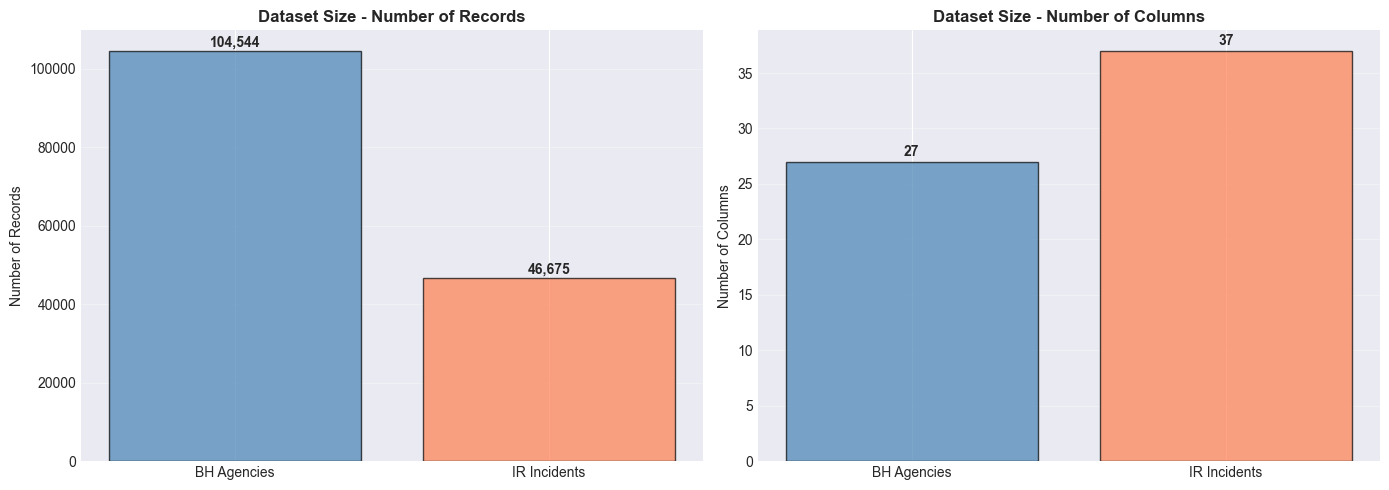

Saved: images_before/01_dataset_comparison.png


In [52]:
# Chart 1: Dataset Size Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = ['BH Agencies', 'IR Incidents']
rows = [bh_decoded.shape[0], ir_decoded.shape[0]]
cols = [bh_decoded.shape[1], ir_decoded.shape[1]]

axes[0].bar(datasets, rows, color=['steelblue', 'coral'], edgecolor='black', alpha=0.7)
axes[0].set_title('Dataset Size - Number of Records', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rows):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(datasets, cols, color=['steelblue', 'coral'], edgecolor='black', alpha=0.7)
axes[1].set_title('Dataset Size - Number of Columns', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Columns')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cols):
    axes[1].text(i, v + 0.5, f'{v}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images_before/01_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images_before/01_dataset_comparison.png")

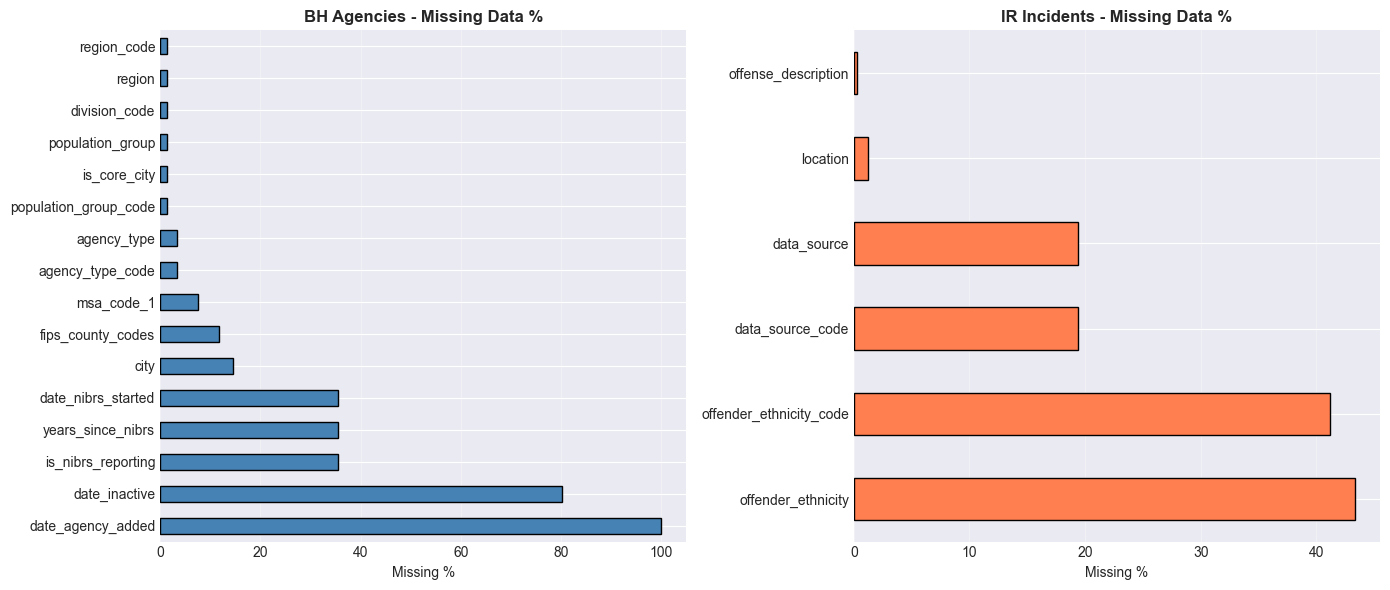

Saved: images_before/02_missing_data_comparison.png


In [53]:
# Chart 2: Missing Data Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bh_missing_pct = (bh_decoded.isna().sum() / len(bh_decoded) * 100).sort_values(ascending=False)
bh_missing_pct = bh_missing_pct[bh_missing_pct > 0]

ir_missing_pct = (ir_decoded.isna().sum() / len(ir_decoded) * 100).sort_values(ascending=False)
ir_missing_pct = ir_missing_pct[ir_missing_pct > 0]

if len(bh_missing_pct) > 0:
    bh_missing_pct.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('BH Agencies - Missing Data %', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Missing %')
    axes[0].grid(True, alpha=0.3, axis='x')
else:
    axes[0].text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('BH Agencies - No Missing Data', fontsize=12, fontweight='bold')

if len(ir_missing_pct) > 0:
    ir_missing_pct.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('IR Incidents - Missing Data %', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Missing %')
    axes[1].grid(True, alpha=0.3, axis='x')
else:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('IR Incidents - No Missing Data', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images_before/02_missing_data_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images_before/02_missing_data_comparison.png")

## 5. Summary of Key Findings

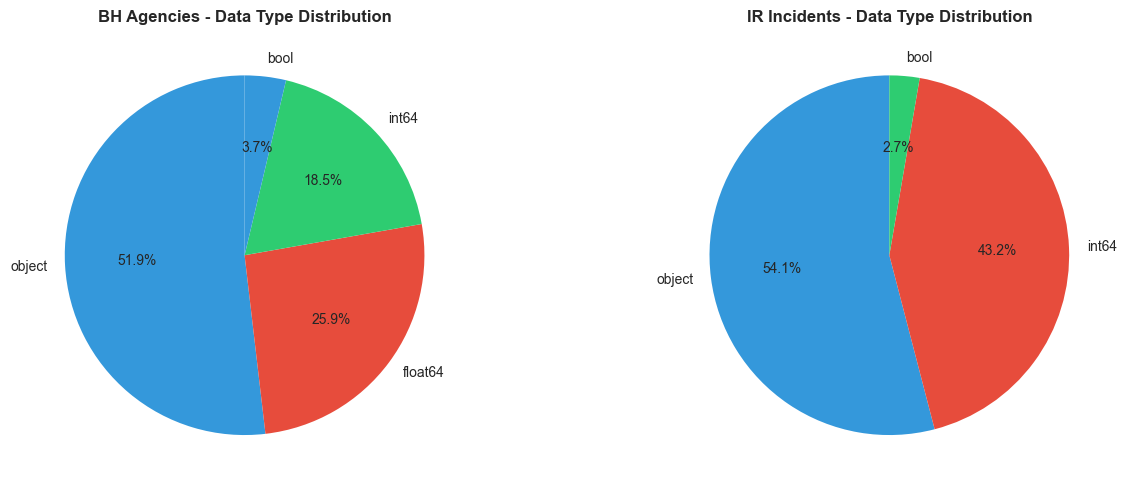

Saved: images_before/03_data_type_distribution.png


In [54]:
# Chart 3: Data Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bh_dtype_counts = bh_decoded.dtypes.value_counts()
ir_dtype_counts = ir_decoded.dtypes.value_counts()

colors = ['#3498db', '#e74c3c', '#2ecc71']

axes[0].pie(bh_dtype_counts.values, labels=bh_dtype_counts.index, autopct='%1.1f%%', 
            colors=colors[:len(bh_dtype_counts)], startangle=90)
axes[0].set_title('BH Agencies - Data Type Distribution', fontweight='bold', fontsize=12)

axes[1].pie(ir_dtype_counts.values, labels=ir_dtype_counts.index, autopct='%1.1f%%', 
            colors=colors[:len(ir_dtype_counts)], startangle=90)
axes[1].set_title('IR Incidents - Data Type Distribution', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('images_before/03_data_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: images_before/03_data_type_distribution.png")

In [55]:
print("\n" + "="*80)
print("SUMMARY: DATA QUALITY ISSUES IN DECODED DATASETS")
print("="*80)

issues = [
    {
        'issue': 'Original files have encoding issues',
        'description': 'BH_raw and IR_raw files contain encoding problems and are not readable directly.',
        'severity': 'CRITICAL',
        'solution': 'Use decoded versions (utf-8 encoding) for all analysis'
    },
    {
        'issue': 'Data type inconsistencies',
        'description': 'Some columns may need type conversion (datetime, categorical, etc)',
        'severity': 'MEDIUM',
        'solution': 'Standardize data types in Phase 2'
    },
    {
        'issue': 'Categorical data uniformity',
        'description': 'Categorical columns may have inconsistent formatting or capitalization',
        'severity': 'MEDIUM',
        'solution': 'Standardize categorical values'
    },
    {
        'issue': 'Missing values handling',
        'description': f'BH missing: {bh_decoded.isna().sum().sum()}, IR missing: {ir_decoded.isna().sum().sum()}',
        'severity': 'MEDIUM',
        'solution': 'Develop strategy for missing value imputation or removal'
    },
    {
        'issue': 'Duplicate records',
        'description': f'BH duplicates: {bh_decoded.duplicated().sum()}, IR duplicates: {ir_decoded.duplicated().sum()}',
        'severity': 'LOW',
        'solution': 'Remove duplicate records in data cleaning'
    }
]

for i, issue in enumerate(issues, 1):
    print(f"\n{'-'*70}")
    print(f"ISSUE {i}: {issue['issue']}")
    print(f"{'-'*70}")
    print(f"  Severity: {issue['severity']}")
    print(f"  Description: {issue['description']}")
    print(f"  Solution: {issue['solution']}")

print(f"\n{'='*80}")


SUMMARY: DATA QUALITY ISSUES IN DECODED DATASETS

----------------------------------------------------------------------
ISSUE 1: Original files have encoding issues
----------------------------------------------------------------------
  Severity: CRITICAL
  Description: BH_raw and IR_raw files contain encoding problems and are not readable directly.
  Solution: Use decoded versions (utf-8 encoding) for all analysis

----------------------------------------------------------------------
ISSUE 2: Data type inconsistencies
----------------------------------------------------------------------
  Severity: MEDIUM
  Description: Some columns may need type conversion (datetime, categorical, etc)
  Solution: Standardize data types in Phase 2

----------------------------------------------------------------------
ISSUE 3: Categorical data uniformity
----------------------------------------------------------------------
  Severity: MEDIUM
  Description: Categorical columns may have inconsiste